In [1]:
import pandas as pd
import pickle as pkl
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from glob import glob

In [10]:
stim_choice_decoders = glob('../data/generated/crosstime_decoders/allcorrect_trained/*.pqt')
prior_decoders = glob('../data/generated/temporal_prior/*.pqt')


In [29]:
reduced_rank_files = glob('../../communication_python/data/generated/rrr_correct_incorrect/*.pkl')

In [113]:
resultsdf = []
for files in reduced_rank_files:
    data = pkl.load(open(files,'rb'))
    session_results = data['results_all_correct']
    session_id = data['session_id']
    for frame_number in range(len(session_results)):

        if (session_results[frame_number]['cv_r2_rrr_correct']>0) & (session_results[frame_number]['perm_naive_p_value']<0.05):
            temp_results = {}
            real_frame = session_results[frame_number]['frame'] + 5
            temp_results['optimal_rank'] = session_results[frame_number]['optimal_rank']
            temp_results['full_r2'] = session_results[frame_number]['cv_full_r2_ridge_correct_test']
            temp_results['r2_correct'] = session_results[frame_number]['cv_r2_rrr_correct']
            temp_results['r2_congruent_incorrect'] = session_results[frame_number]['r2_cong_incorrect']
            temp_results['r2_incongruent_incorrect'] = session_results[frame_number]['r2_incong_incorrect']
            temp_results['frame'] = real_frame
            temp_results['eid'] = session_id
        resultsdf.append(temp_results)

In [114]:
rrr_df = pd.DataFrame(resultsdf)

In [115]:
rrr_df

,optimal_rank,full_r2,r2_correct,r2_congruent_incorrect,r2_incongruent_incorrect,frame,eid
0,2,0.152739,0.140261,0.246048,-0.094978,0,8ba20ff9-d74f-42f0-b7bf-0a4c350ba53c
1,2,0.168371,0.151336,0.246594,-0.171950,1,8ba20ff9-d74f-42f0-b7bf-0a4c350ba53c
2,1,0.117023,0.098734,0.082104,-0.150230,2,8ba20ff9-d74f-42f0-b7bf-0a4c350ba53c
3,2,0.034238,0.028062,0.019806,-0.126255,3,8ba20ff9-d74f-42f0-b7bf-0a4c350ba53c
4,1,-0.001238,0.004277,0.009955,-0.158591,4,8ba20ff9-d74f-42f0-b7bf-0a4c350ba53c
...,...,...,...,...,...,...,...
235,1,0.139086,0.095247,-0.131415,0.203906,0,7665dd63-7bda-430f-9425-054a2ddc3ea1
236,1,0.132935,0.080801,-0.016410,0.160626,1,7665dd63-7bda-430f-9425-054a2ddc3ea1
237,3,0.163609,0.126898,-0.197592,0.073314,2,7665dd63-7bda-430f-9425-054a2ddc3ea1
238,2,0.105621,0.101230,-0.092973,-0.042325,3,7665dd63-7bda-430f-9425-054a2ddc3ea1


In [116]:
df_melted = rrr_df.melt(
    id_vars=['frame', 'eid'],
    value_vars=['r2_correct', 'r2_congruent_incorrect', 'r2_incongruent_incorrect'],
    var_name='Condition',
    value_name='R2'
)

In [117]:
df_melted['Condition'] = (
    df_melted['Condition']
    .str.replace('r2_', '')
    .str.replace('_', ' ')
    .str.title()
)

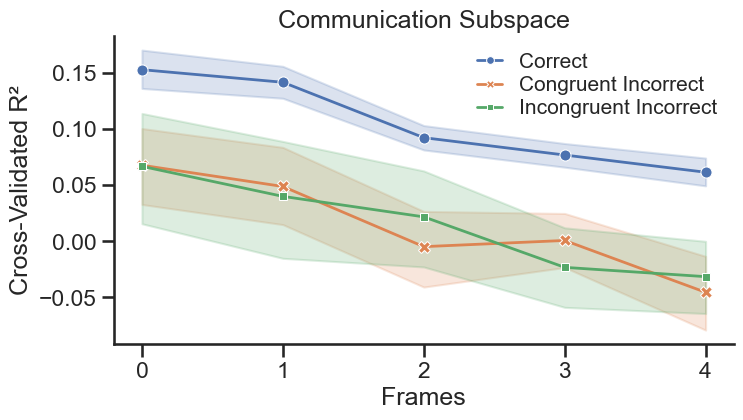

In [126]:
fig, ax = plt.subplots(figsize=(8,4))
sns.lineplot(
    data=df_melted,
    x='frame',
    y='R2',
    hue='Condition',
    style='Condition',
    markers=True,
    dashes=False,
    linewidth=2,
    markersize=8,
    ax=ax,
    errorbar=("ci"),
)
ax.set_title('Communication Subspace')
ax.set_xlabel('Frames')
ax.set_ylabel('Cross-Validated R²')
ax.legend(
    fontsize='small',   
    markerscale=0.7,    
    handlelength=1.2,   
    labelspacing=0.2,   
    borderpad=0.3,      
    framealpha=0.      
)
ax.set_xticks(np.arange(5))
sns.despine()

In [129]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

/var/folders/nr/dw4dxrwd2r3ctns0lnz88jjc0000gn/T/ipykernel_18564/2470145832.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


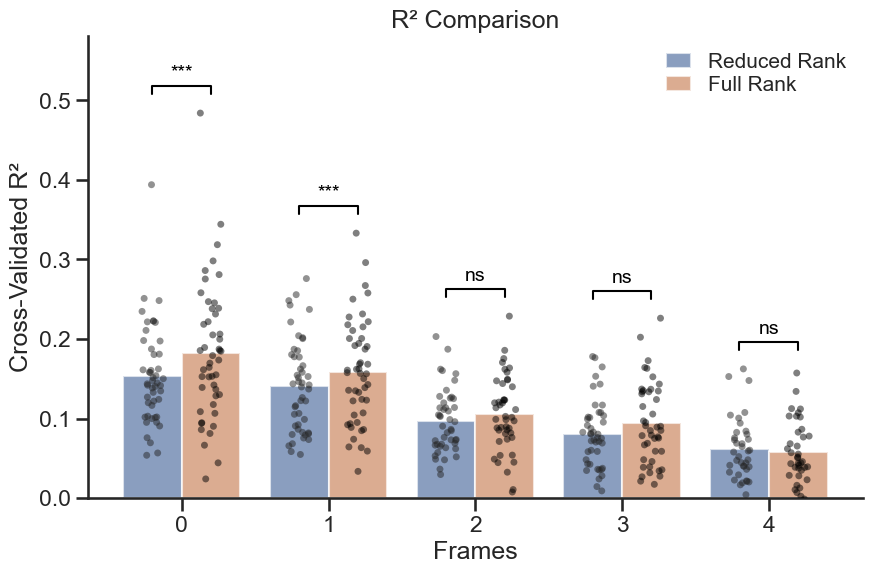

In [143]:
df_animal = rrr_df.groupby(['eid', 'frame'])[['r2_correct', 'full_r2']].mean().reset_index()

df_melted = df_animal.melt(
    id_vars=['frame', 'eid'],
    value_vars=['r2_correct', 'full_r2'],
    var_name='Model',
    value_name='R2'
)
df_melted['Model'] = df_melted['Model'].replace({'r2_correct': 'Reduced Rank', 'full_r2': 'Full Rank'})

# 2. CALCULATE STATISTICS AND APPLY FDR CORRECTION FIRST
frames = sorted(df_animal['frame'].unique())
raw_p_values = []

for frame in frames:
    data_frame = df_animal[df_animal['frame'] == frame].dropna(subset=['r2_correct', 'full_r2'])
    v1 = data_frame['r2_correct']
    v2 = data_frame['full_r2']
    stat, p_val = wilcoxon(v1, v2)
    raw_p_values.append(p_val)

# Apply Benjamini-Hochberg FDR correction across the frames
reject, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

# 3. PLOT
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="ticks", context="talk")

sns.barplot(
    data=df_melted,
    x='frame',
    y='R2',
    hue='Model',
    errorbar=None, 
    alpha=0.7,
    ax=ax
)

sns.stripplot(
    data=df_melted,
    x='frame',
    y='R2',
    hue='Model',
    dodge=True,
    color='black',
    alpha=0.5,
    jitter=0.15,
    ax=ax,
    legend=False
)

# 4. ANNOTATE WITH CORRECTED P-VALUES
y_max_overall = df_animal[['r2_correct', 'full_r2']].max().max()

for i, (frame, p_cor) in enumerate(zip(frames, pvals_corrected)):
    # Assign significance marker based on the CORRECTED p-value
    if p_cor < 0.001:
        sig_symbol = '***'
    elif p_cor < 0.01:
        sig_symbol = '**'
    elif p_cor < 0.05:
        sig_symbol = '*'
    else:
        sig_symbol = 'ns'
        
    # print(f"Frame {frame}: Raw p={raw_p_values[i]:.4f} | FDR Corrected p={p_cor:.4f} ({sig_symbol})")
    
    # Get local Y max for bracket placement
    data_frame = df_animal[df_animal['frame'] == frame]
    local_y_max = max(data_frame['r2_correct'].max(), data_frame['full_r2'].max())
    y_text = local_y_max + (y_max_overall * 0.05)
    
    x1, x2 = i - 0.2, i + 0.2
    
    ax.plot([x1, x1, x2, x2], [y_text, y_text+0.01, y_text+0.01, y_text], lw=1.5, color='black')
    ax.text((x1+x2)*.5, y_text + 0.015, sig_symbol, ha='center', va='bottom', color='black', fontsize=14)

ax.set_title('R² Comparison')
ax.set_xlabel('Frames')
ax.set_ylabel('Cross-Validated R²')
ax.set_ylim(bottom=0, top=y_max_overall * 1.2)

ax.legend(
    fontsize='small',   
    markerscale=0.7,    
    handlelength=1.2,   
    labelspacing=0.2,   
    borderpad=0.3,      
    framealpha=0.      
)
sns.despine()

plt.show()

In [137]:
q = rrr_df[rrr_df['frame']==0][['full_r2','r2_correct']].copy()

### plot the stimulus, and choice and prior decoders

In [144]:
df = pd.read_csv('../../ibl-partial-info-decomp/data/external/region_info.csv')

In [151]:
x = df[df['prior_dec_wf_sig']==1][['Beryl','prior_dec_wf']].copy()

In [152]:
x.sort_values(by='prior_dec_wf', inplace=True)

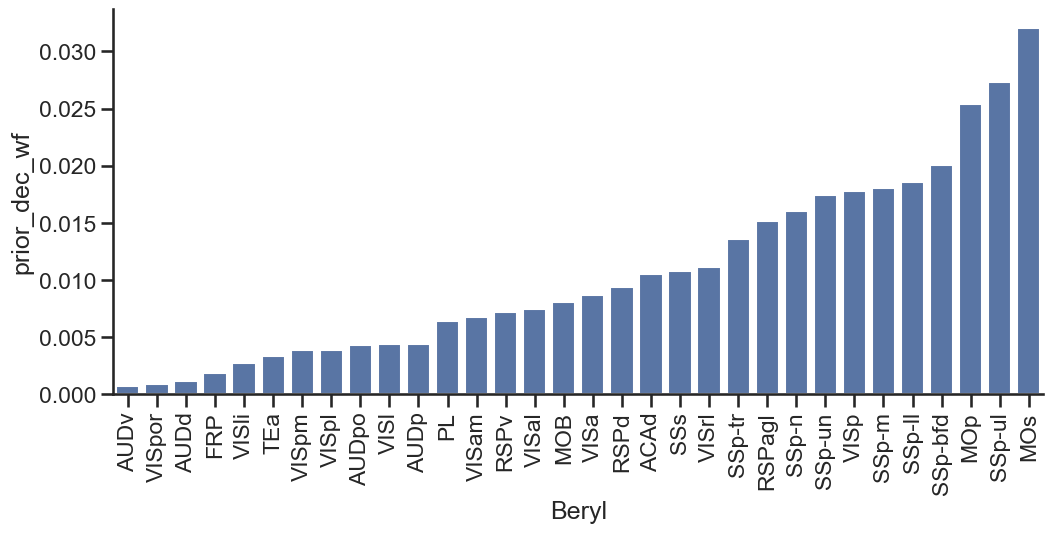

In [159]:
fig,ax = plt.subplots(figsize=(12,5))
sns.barplot(x,x='Beryl',y='prior_dec_wf')
ax.set_xticks(np.arange(len(x)), labels=x['Beryl'],rotation=90)
sns.despine()

In [3]:
reduced_rank_files = glob('../../communication_python/data/generated/widefield_projections/prior_window/*.pkl')